In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ------------------------------------ - 51.2/52.8 kB 217.9 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 209.8 kB/s eta 0:00:00
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.8 kB ? eta -:--:--
     ------------- -------------------------- 41.0/119.8 kB ? eta -:--:--
     ------------------ ------------------ 61.4/119.8 kB 825.8 kB/s eta 0:00:01
     --------------------------------- -- 112


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Cell 1 — Import Libraries ###

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

### Cell 2 — Load Dataset ###

In [46]:
df = pd.read_csv(r"D:\UAC_Care_Analytices\data\uac_data.csv")

### Cell 3 — Check Dataset Information ###

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    str    
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    str    
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), str(2)
memory usage: 55.0 KB


### Cell 4 — Convert Date Column

In [48]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.set_index("Date", inplace=True)


df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,"6,566",436.0
2023-01-22,32.0,49.0,39.0,"7,122",227.0
2023-01-23,32.0,50.0,39.0,"7,280",181.0
2023-01-24,47.0,42.0,47.0,"7,433",175.0
2023-01-25,20.0,22.0,41.0,"7,538",180.0


### Cell 5 — Check Missing Values

In [49]:
df.isnull().sum()



Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

### Cell 6 — Basic Statistics

In [50]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


### Cell 7 — Create Total System Load

In [51]:
import pandas as pd

# Load data
df = pd.read_csv("../data/uac_data.csv")

# Fix column names (remove hidden spaces)
df.columns = df.columns.str.strip()

# Convert Date
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
df.set_index("Date", inplace=True)

# Columns to clean
cols = [
    "Children in CBP custody",
    "Children transferred out of CBP custody",
    "Children in HHS Care",
    "Children discharged from HHS Care"
]

# Clean each column PROPERLY
for col in cols:
    df[col] = df[col].astype(str)                 # force string
    df[col] = df[col].str.replace(",", "", regex=False)  # remove commas
    df[col] = df[col].str.replace("-", "", regex=False)  # remove dashes
    df[col] = df[col].str.strip()                 # remove spaces
    df[col] = pd.to_numeric(df[col], errors="coerce")  # convert

# Fill missing values
df = df.ffill()

# 🔍 VERIFY (VERY IMPORTANT)
print(df[cols].dtypes)
print(df[cols].head())

Children in CBP custody                    float64
Children transferred out of CBP custody    float64
Children in HHS Care                       float64
Children discharged from HHS Care          float64
dtype: object
            Children in CBP custody  Children transferred out of CBP custody  \
Date                                                                           
2023-01-12                     53.0                                     34.0   
2023-01-22                     49.0                                     39.0   
2023-01-23                     50.0                                     39.0   
2023-01-24                     42.0                                     47.0   
2023-01-25                     22.0                                     41.0   

            Children in HHS Care  Children discharged from HHS Care  
Date                                                                 
2023-01-12                6566.0                              436.0  
2023-01-22 

In [14]:
df["Total_System_Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)


df.head()


,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Total_System_Load
Date,,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0,6619.0
2023-01-22,32.0,49.0,39.0,7122.0,227.0,7171.0
2023-01-23,32.0,50.0,39.0,7280.0,181.0,7330.0
2023-01-24,47.0,42.0,47.0,7433.0,175.0,7475.0
2023-01-25,20.0,22.0,41.0,7538.0,180.0,7560.0


In [52]:
print(df.columns)

Index(['Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='str')


In [53]:
df["Children in CBP custody"] = pd.to_numeric(df["Children in CBP custody"], errors="coerce")

df["Children in HHS Care"] = pd.to_numeric(df["Children in HHS Care"], errors="coerce")

df["Children transferred out of CBP custody"] = pd.to_numeric(
    df["Children transferred out of CBP custody"], errors="coerce"
)

df["Children discharged from HHS Care"] = pd.to_numeric(
    df["Children discharged from HHS Care"], errors="coerce"
)

In [54]:
df = df.ffill()

In [55]:
numeric_cols = [
"Children in CBP custody",
"Children transferred out of CBP custody",
"Children in HHS Care",
"Children discharged from HHS Care"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.ffill()

df.head()



,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-22,32.0,49.0,39.0,7122.0,227.0
2023-01-23,32.0,50.0,39.0,7280.0,181.0
2023-01-24,47.0,42.0,47.0,7433.0,175.0
2023-01-25,20.0,22.0,41.0,7538.0,180.0


### Cell 8 — Net Daily Intake

In [56]:
df["Total_System_Load"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)



### Cell 9 — Care Load Growth Rate

In [57]:
df["Load_Growth_Rate"] = df["Total_System_Load"].pct_change() * 100

df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Total_System_Load,Load_Growth_Rate
Date,,,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0,6619.0,NaN
2023-01-22,32.0,49.0,39.0,7122.0,227.0,7171.0,8.339628
2023-01-23,32.0,50.0,39.0,7280.0,181.0,7330.0,2.217264
2023-01-24,47.0,42.0,47.0,7433.0,175.0,7475.0,1.978172
2023-01-25,20.0,22.0,41.0,7538.0,180.0,7560.0,1.137124


### Cell 10 — Plot Total System Load

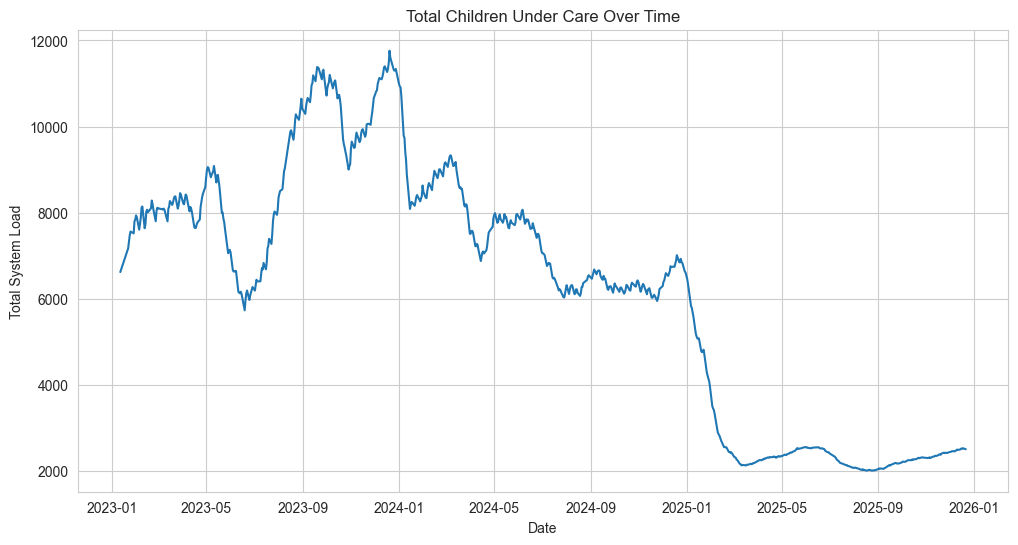

In [58]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Total_System_Load"])

plt.title("Total Children Under Care Over Time")

plt.xlabel("Date")
plt.ylabel("Total System Load")

plt.show()



### Cell 11 — Compare CBP vs HHS

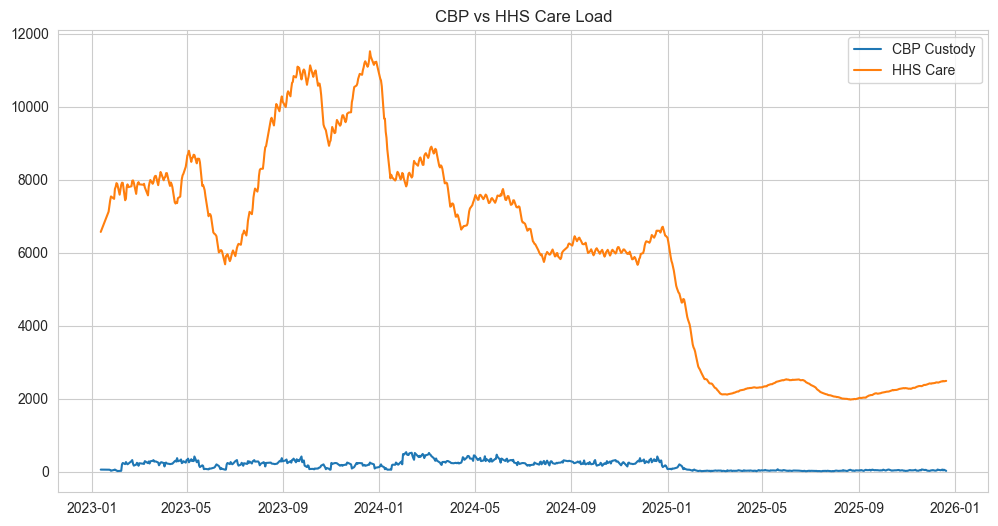

In [59]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Children in CBP custody"], label="CBP Custody")

plt.plot(df.index, df["Children in HHS Care"], label="HHS Care")

plt.title("CBP vs HHS Care Load")

plt.legend()

plt.show()


### Cell 12 — Net Intake Trend

In [60]:
print(df.columns)

Index(['Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care',
       'Total_System_Load', 'Load_Growth_Rate'],
      dtype='str')


In [61]:
df["Net_Daily_Intake"] = (
    df["Children transferred out of CBP custody"]
    - df["Children discharged from HHS Care"]
)

df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Total_System_Load,Load_Growth_Rate,Net_Daily_Intake
Date,,,,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0,6619.0,NaN,-402.0
2023-01-22,32.0,49.0,39.0,7122.0,227.0,7171.0,8.339628,-188.0
2023-01-23,32.0,50.0,39.0,7280.0,181.0,7330.0,2.217264,-142.0
2023-01-24,47.0,42.0,47.0,7433.0,175.0,7475.0,1.978172,-128.0
2023-01-25,20.0,22.0,41.0,7538.0,180.0,7560.0,1.137124,-139.0


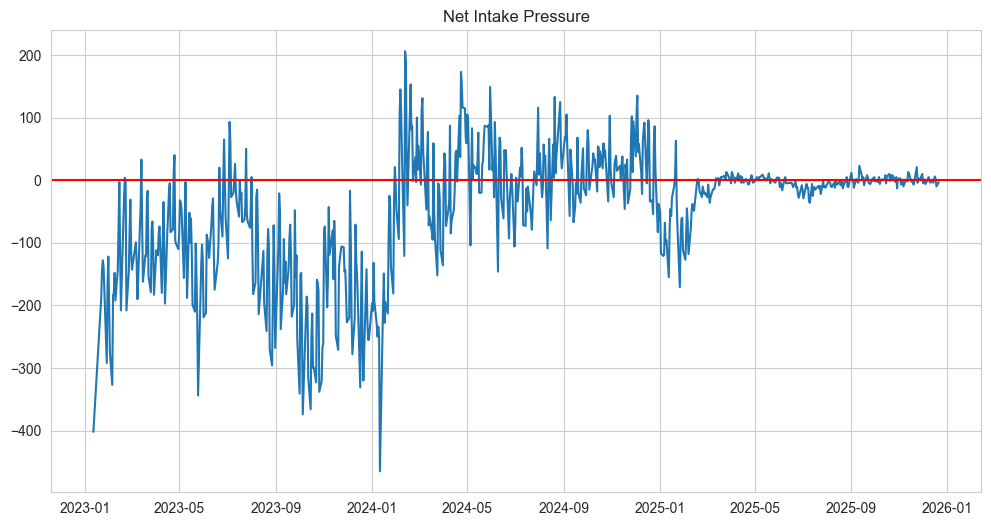

In [62]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Net_Daily_Intake"])

plt.title("Net Intake Pressure")


plt.axhline(0, color="red")

plt.show()


### Cell 13 — Rolling Average (Stress Detection)

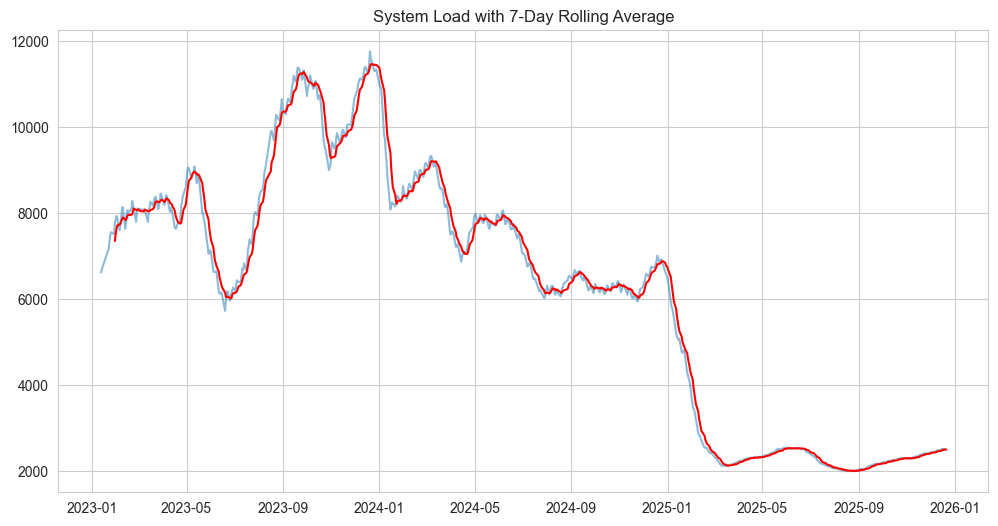

In [63]:
df["Rolling_7D"] = df["Total_System_Load"].rolling(7).mean()

plt.figure(figsize=(12,6))

plt.plot(df.index, df["Total_System_Load"], alpha=0.5)


plt.plot(df.index, df["Rolling_7D"], color="red")

plt.title("System Load with 7-Day Rolling Average")

plt.show()

### Cell 14 — Volatility Analysis

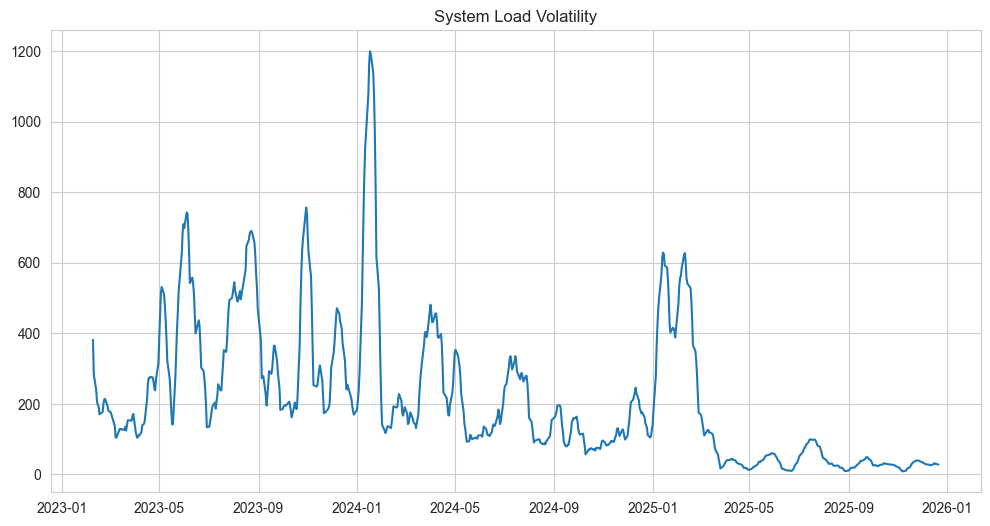

In [64]:
df["Volatility"] = df["Total_System_Load"].rolling(14).std()

plt.figure(figsize=(12,6))

plt.plot(df.index, df["Volatility"])

plt.title("System Load Volatility")


plt.show()

### Cell 15 — Correlation Heatmap

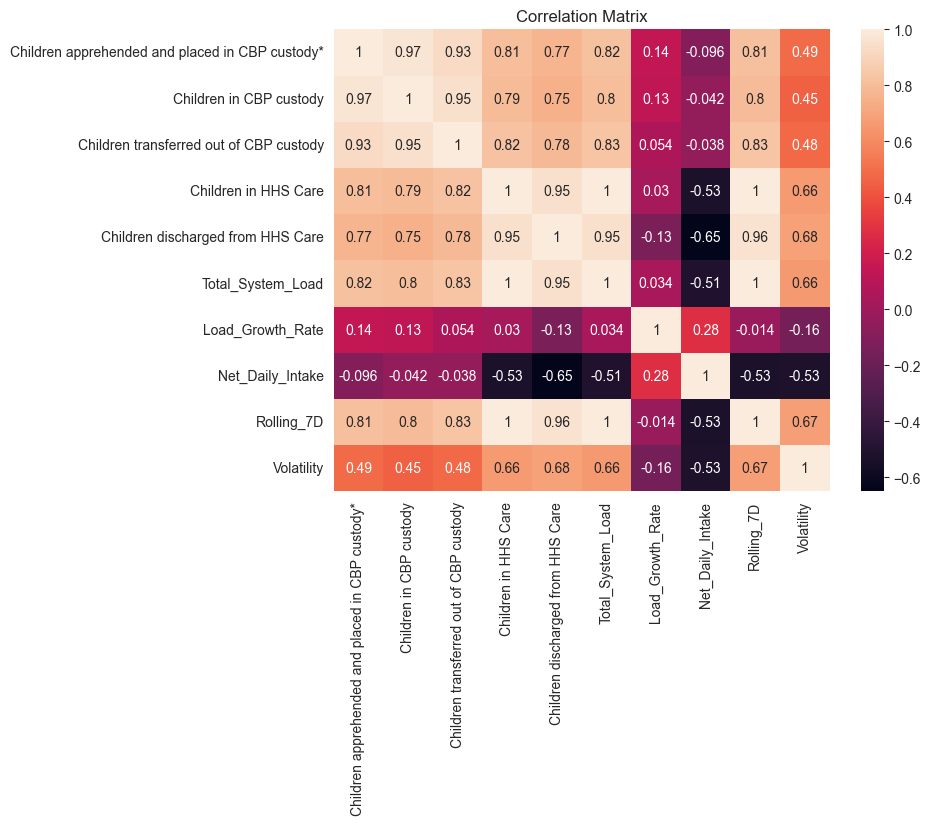

In [65]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True)

plt.title("Correlation Matrix")

plt.show()




### Cell 16 — Monthly Trends

In [66]:
monthly = df.resample("ME").mean()

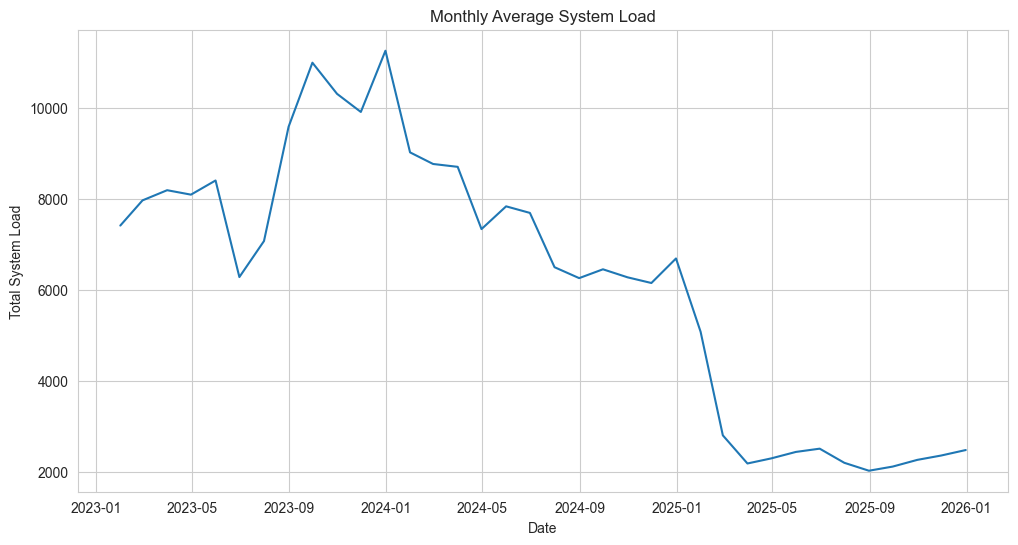

In [67]:

monthly = df.resample("ME").mean()

import matplotlib.pyplot as plt



plt.figure(figsize=(12,6))

plt.plot(monthly.index, monthly["Total_System_Load"])

plt.title("Monthly Average System Load")

plt.xlabel("Date")
plt.ylabel("Total System Load")

plt.show()

### Cell 17 — Backlog Indicator ###

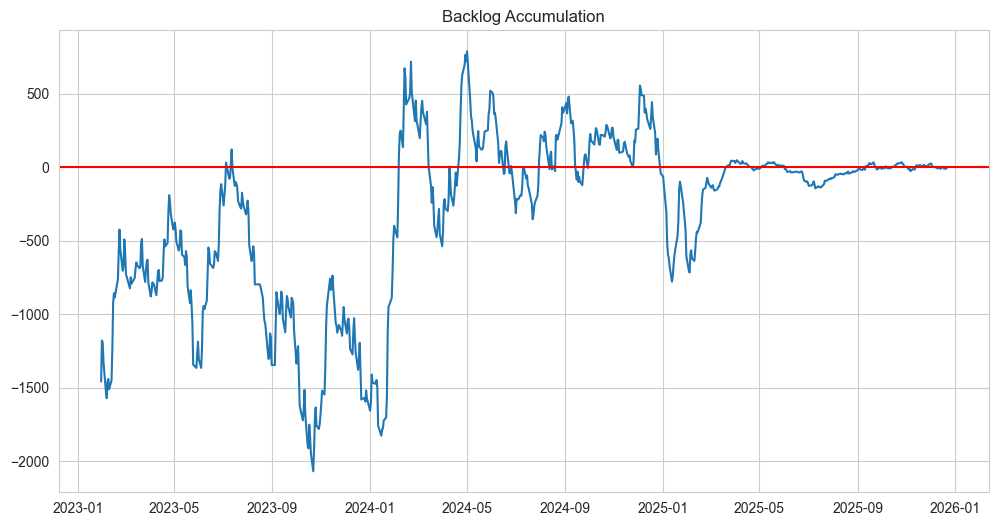

In [68]:
df["Backlog"] = df["Net_Daily_Intake"].rolling(7).sum()

plt.figure(figsize=(12,6))

plt.plot(df.index, df["Backlog"])

plt.title("Backlog Accumulation")

plt.axhline(0, color="red")

plt.show()

## Key Insights

1. Total system load shows increasing trend during peak periods.
2. Net intake remained positive for extended periods, indicating backlog formation.
3. Discharge rates were insufficient to offset intake during high-load phases.
4. Rolling averages highlight sustained pressure windows.
5. Volatility spikes indicate instability in system capacity.
6. Monthly trends show long-term growth in care demand.

### Forecasting ###

In [69]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
df = df.ffill()

X = np.arange(len(df)).reshape(-1,1)
y = df["Total_System_Load"]

# Train model
model = LinearRegression()
model.fit(X,y)

# Predict next 30 days
future_days = np.arange(len(df), len(df)+30).reshape(-1,1)
forecast = model.predict(future_days)

print(forecast)

[539.34324172 532.0699456  524.79664948 517.52335336 510.25005724
 502.97676112 495.70346501 488.43016889 481.15687277 473.88357665
 466.61028053 459.33698441 452.06368829 444.79039217 437.51709605
 430.24379993 422.97050381 415.69720769 408.42391157 401.15061545
 393.87731933 386.60402321 379.33072709 372.05743097 364.78413485
 357.51083874 350.23754262 342.9642465  335.69095038 328.41765426]


ValueError: Neither `start` nor `end` can be NaT

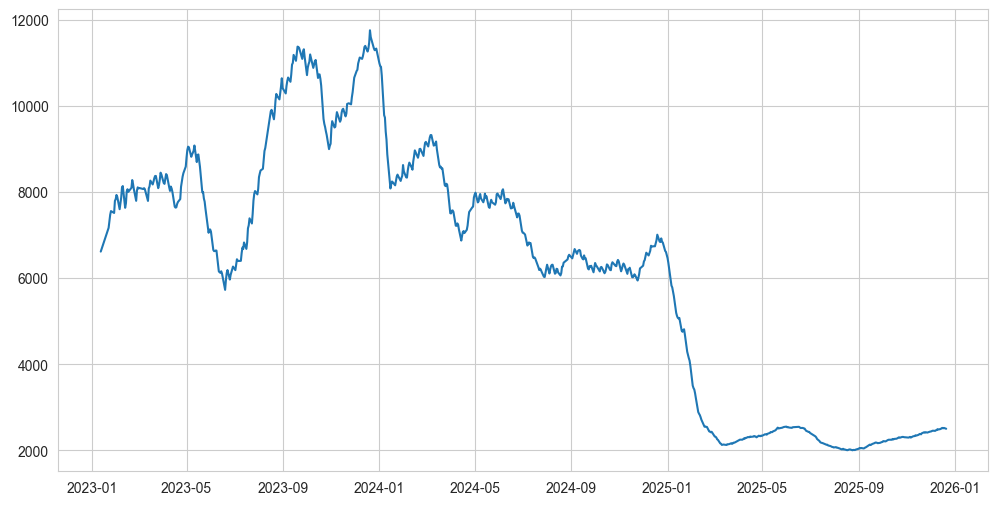

In [71]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["Total_System_Load"], label="Actual")

future_dates = pd.date_range(df.index[-1], periods=30)

plt.plot(future_dates, forecast, label="Forecast", color="red")

plt.legend()

plt.title("System Load Forecast")

plt.show()